In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Introduction

For this project, the data set is composed of GDP growth percentages for a set of US economic quarters rangin from 2010 to 2023. The project will use Cubic Spline Interpolation, Least Squares Linear Regression, and Polynomial Fitting in order to determine which method would be best to interpolate the missing data points. Since the data includes a period of outliers during Covid, some of these methods will use a filtered data set that eliminates any outliers. 

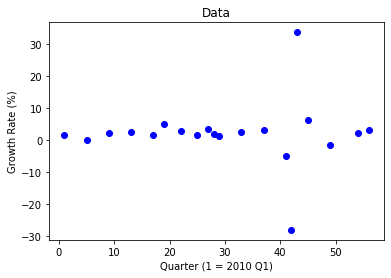

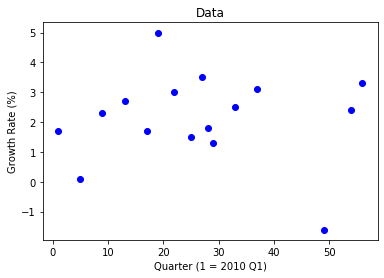

In [2]:
# Given Data
quarters = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 56])
growth = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

# Filtered data without the Covid data
qfilter = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 49, 54, 56])
gfilter = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -1.6, 2.4, 3.3])

# Data Plotted
plt.scatter(quarters, growth, color = 'blue')
plt.title("Data")
plt.xlabel("Quarter (1 = 2010 Q1)")
plt.ylabel("Growth Rate (%)")
plt.show()
plt.scatter(qfilter,gfilter, color = 'blue')
plt.title("Data")
plt.xlabel("Quarter (1 = 2010 Q1)")
plt.ylabel("Growth Rate (%)")
plt.show()

## PART A: Cubic Spline Interpolation

In [3]:
# Solves the tridiagonal system of equations
def thomas_algorithm(a, b, c, d):
    n = len(b)

    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]

    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

In [4]:
# Builds the tridiagonal system of equations
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # h_i = x_{i+1} - x_i
 
    A = np.zeros(n - 2)
    B = np.zeros(n - 2)
    C = np.zeros(n - 2)
    D = np.zeros(n - 2)
 
    for i in range(1, n - 1):
        A[i - 1] = h[i - 1]
        B[i - 1] = 2 * (h[i - 1] + h[i])
        C[i - 1] = h[i]
        D[i - 1] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])
 
    return A, B, C, D

In [5]:
# Computes the second derivatives of the system
def compute_second_derivatives(x, y):
    n = len(x)
    A, B, C, D = setup_tridiagonal_matrix(x, y)
    M_interior = thomas_algorithm(A, B, C, D)
    M = np.zeros(n)
    M[1:-1] = M_interior
    return M

In [6]:
# Evaluates the actual spline given the second derivatives
def evaluate_spline(x, y, M, x_eval):
    h      = np.diff(x)
    y_eval = np.zeros_like(x_eval, dtype=float)
    for j, xval in enumerate(x_eval):
        i        = int(np.clip(np.searchsorted(x, xval, side='right') - 1, 0, len(x) - 2))
        hi       = h[i]
        dx_right = x[i + 1] - xval
        dx_left  = xval - x[i]
        term1 = M[i]     / (6 * hi) * dx_right**3
        term2 = M[i + 1] / (6 * hi) * dx_left**3
        term3 = (y[i]     / hi - M[i]     * hi / 6) * dx_right
        term4 = (y[i + 1] / hi - M[i + 1] * hi / 6) * dx_left
        y_eval[j] = term1 + term2 + term3 + term4
    return y_eval

In [7]:
# Puts everything together to perfrom the interpolation
def cubic_spline_interpolation(x_data, y_data, step=0.01):
    x = np.array(x_data, dtype=float)
    y = np.array(y_data, dtype=float)
 
    A, B, C, D = setup_tridiagonal_matrix(x, y)
    print("Subdiagonal  (A):", A)
    print("Main diagonal(B):", B)
    print("Superdiagonal(C):", C)
    print("Right-hand   (D):", D)
 
    M = compute_second_derivatives(x, y)
    print("\nSecond derivatives M:", M)
 

    x_fine = np.arange(x[0], x[-1] + step, step)
    y_fine = evaluate_spline(x, y, M, x_fine)

Subdiagonal (A): [4. 4. 4. 4. 2. 3. 3. 2. 1. 1. 4. 4. 4. 1. 1. 2. 4. 5.]
Main diagonal (B): [16. 16. 16. 12. 10. 12. 10.  6.  4. 10. 16. 16. 10.  4.  6. 12. 18. 14.]
Superdiagonal (C): [4. 4. 4. 2. 3. 3. 2. 1. 1. 4. 4. 4. 1. 1. 2. 4. 5. 2.]
Right-hand side (D): [   5.7    -2.7    -2.1    11.4   -13.9     1.      9.    -16.2     7.2
    4.8    -0.9   -13.2  -125.7   509.4  -453.9    70.65   16.65   -2.1 ]
[ 0.00000000e+00  3.95092366e-01 -1.55369464e-01 -4.48614511e-01
  1.42482751e+00 -1.95173602e+00 -2.73165986e-02  1.74375708e+00
 -4.17781049e+00  3.63559168e+00  1.01325424e+00 -2.24203352e+00
  8.48982050e+00 -3.50172485e+01  1.90513203e+02 -1.12583818e+02
  1.55448525e+01 -8.26102883e-01  8.60293952e-02  0.00000000e+00]


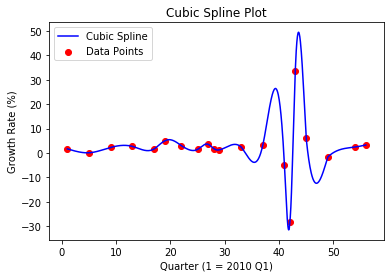

In [8]:
# Assigning quarters and growth to x and y to make it easier
x = quarters
y = growth
 
# Setting up matrix
A, B, C, D = setup_tridiagonal_matrix(x, y)
print("Subdiagonal (A):", A)
print("Main diagonal (B):", B)
print("Superdiagonal (C):", C)
print("Right-hand side (D):", D)
 
#Finding matrix
M = thomas_algorithm(A, B, C, D)
M = np.insert(M, 0, 0)
M = np.append(M, 0)
print(M)
 
# Evaluate and plot
xeval = np.linspace(min(quarters), max(quarters), 1000)
yeval = evaluate_spline(x, y, M, xeval)


plt.plot(xeval, yeval, color='blue', label='Cubic Spline')
plt.scatter(x, y, color='red', label='Data Points')
plt.xlabel('x')
plt.ylabel('y')
plt.title("Cubic Spline Plot")
plt.xlabel("Quarter (1 = 2010 Q1)")
plt.ylabel("Growth Rate (%)")
plt.legend()
plt.show()

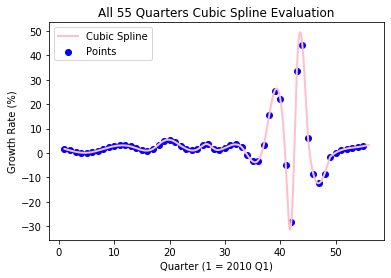

In [9]:
# Interpolating for all 55 of the values
x_interp=np.arange(1,56)
y_interp = evaluate_spline(quarters,growth,M,x_interp)

# Plotting these values
plt.scatter(x_interp, y_interp, color='blue', label='Points')
plt.plot(xeval, yeval, color='pink', linewidth=2, label='Cubic Spline')
plt.title("All 55 Quarters Cubic Spline Evaluation")
plt.xlabel("Quarter (1 = 2010 Q1)")
plt.ylabel("Growth Rate (%)")
plt.legend()
plt.show()

### Part A Discussion

1. With twenty data points, since we are solving for n-2, there are 18 unknowns. The boundary conditions must be satisfied in this case by setting the endpoints at M=0 meaning there is no curvature at these points. Continuty of the function, first derivative, and second derivative at interior knots is enforced which produces the tridiagonal system.

2. Evaluate the cubic spline at all 55 quantities from 1 to 56 produces a visually smooth interpolation for the data range. The spline passes through every points and there are no sharp corners or jumps in the curve. However, around the 41-45 mark, there are a set of sharp oscilattions due to the presence of outliers from the Covid years. 

3. The Runge phenomenom refers to the tendency of polynomials and splines to create large oscialltions around outliers in the data. In this case, the phenomenom occurs during the Covid quarters, causing the sharp jumps shown in the graph. The highlights of the trade-off between interpolation and numerical stability are that although the spline promises to pass through every point, this comes at the cost of large spikles due to outliers. These could be fixed by either smoothings plines or weighted least squares. In this case, since there is only a small population of Covid outliers. The weighted least squares would allow the spline to follow through any point while also minimizing the extreme effect the outliers have on the overall interpolation and without having to affect the other points.

## PART B: Polynomial and Least Squares Regression

In [10]:
# Custom least squares
def my_lstq(x, y):
    n = len(x)
    xsum = np.sum(x)
    ysum = np.sum(y)
    xysum = np.sum(x*y)
    xxsum = np.sum(x**2)
    m = (n * xysum - xsum * ysum) / (n * xxsum - xsum**2)
    b = (ysum - m * xsum) / n
    return m, b

m =  -0.001906988188976378 
 b =  2.194285187007874
RMSE: 1.4431864883291987


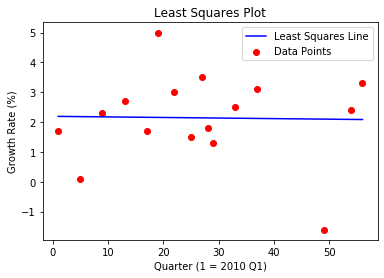

In [11]:
# Solving the least squares for the filtered data
mcus, bcus = my_lstq(qfilter,gfilter)
print ("m = ", mcus, "\n", "b = ", bcus)

# Linear Equation
y1 = mcus*qfilter + bcus

# Finding RMSE
rmse_l = np.sqrt(np.mean((gfilter - y1)**2))
print("RMSE:", rmse_l)

# Plotting
plt.scatter(qfilter, gfilter, color='red', label='Data Points')
plt.plot(qfilter, y1, color = 'blue', label = 'Least Squares Line')
plt.title("Least Squares Plot")
plt.xlabel("Quarter (1 = 2010 Q1)")
plt.ylabel("Growth Rate (%)")
plt.legend()
plt.show()


[-0.4923782  -2.08475025  0.12287771  0.53050566 -0.46186639  2.84194759
  0.84766855 -0.64661048  1.35720349 -0.34088952 -0.83898253  0.36864542
  0.97627338 -3.70084277  0.30869218  1.21250615]


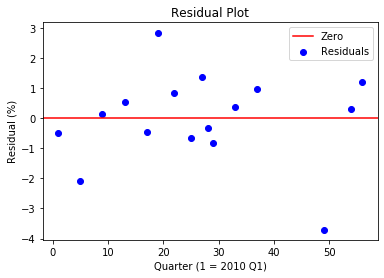

In [12]:
# Finding Residuals
residuals = gfilter - y1
print(residuals)

#Plotting Residuals
plt.scatter(qfilter, residuals, color='blue', label='Residuals')
plt.title("Residual Plot")
plt.axhline(0,color='red',label='Zero')
plt.xlabel("Quarter (1 = 2010 Q1)")
plt.ylabel("Residual (%)")
plt.legend()
plt.show()

Condition: 18197798.189107887


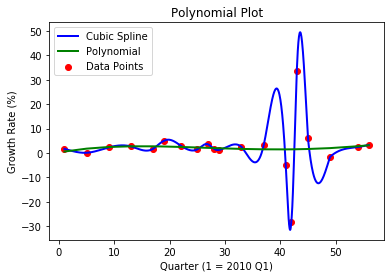


Vandermonde Polynomial Fit
MSE: 100.62980208981799
R^2: 0.0035410151185396588
RMSE: 10.031440678677116


In [13]:
# Setting x and y

x = np.array(quarters)
y = np.array(growth)

# MSE and R^2 functions
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def r_squared(y_true, y_pred):
    ss_total = np.sum((y_true - np.mean(y_true))**2)
    ss_res = np.sum((y_true - y_pred)**2)
    return 1 - (ss_res/ss_total)

# Degree
degree = 4

V = np.vander(x, degree+1)

coeffs_v = np.linalg.lstsq(V,y,rcond=None)[0]

# Checking COndition
print("Condition:", np.linalg.cond(V))

y_vander = V @ coeffs_v

# Plotting
plt.scatter(quarters, growth, color='red', label='Data Points')
plt.plot(xeval, yeval, color='blue', linewidth=2, label='Cubic Spline')
plt.plot(x, y_vander, color='green', linewidth=2, label='Polynomial')
plt.title("Polynomial Plot")
plt.xlabel("Quarter (1 = 2010 Q1)")
plt.ylabel("Growth Rate (%)")
plt.legend()
plt.show()

# Getting MSE and R^2
mse_v = mse(y,y_vander)
r2_v = r_squared(y,y_vander)

rmse_poly = np.sqrt(mse_v)

print("\nVandermonde Polynomial Fit")
print("MSE:",mse_v)
print("R^2:",r2_v)
print("RMSE:",rmse_poly)


[  1.09661096  -1.69114449  -0.16628338  -0.04784395  -1.04435453
   2.33324264   0.51253461  -0.76378933   1.39408135  -0.22765871
  -0.65122054   0.81738429   1.5860465   -6.59070265 -29.61193813
  32.25505835   4.65217805  -3.60976026  -0.37044427   0.12800349]


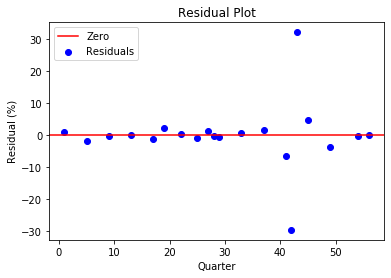

In [14]:
# Finding Residuals
residualv = growth - y_vander
print(residualv)

# Plotting Residuals
plt.scatter(quarters, residualv, color='blue', label='Residuals')
plt.axhline(0,color='red',label='Zero')
plt.title("Residual Plot")
plt.xlabel("Quarter")
plt.ylabel("Residual (%)")
plt.legend()
plt.show()

### Part B: Discussion

1. In this case, the cubic spline is exceptional for reproducing specific data points since that is the whole reason for interpolation. However, the polynomial (Vandermonde fit) is more favorable for capturing the overall trend since it better focuses on the bigger picture instead of letting outliers create unrealistic curves. This means that for interpolation, the spline guarantees an extremely accurate reproduction of data points while being sensitive to outliers. On the approximation end, the polynomial is a stronger choice but it will struggle when the data contains numerous large outliers.

2. The slope for the least squares linear regression is m=-0.001906988188976378. It also contains an intercept of 2.194285187007874 and am RMSE value of 1.4431864883291987. These values all seem good, however, the only catch is that this only applies to the data excluding the Covid quarters. Therefore, the linear trend does make sense on the assumptions that there are no outliers from the Covid quarters and that the rate of the change of the GDP growth remains constant throughout the quarters.  In reality however, this fit would not hold up due to business cycles and outliers from real-world events.

## PART C

I would recommend a cubic spline. Beginning with the smoothness of the fit, the cubic spline has the unique ability to pass through every single point. This means that the interpolated data will be the most accurate method between known data points. On the other hand, polynomial fitting is far less accurate in both the least squares linear regression and the Vandermonde cases. Although the for the linear regression the RMSE value is acceptable, that is only possible if we get rid of the outliers. Since the trends in the data are pretty linear (outside of the outliers) as evidenced by the graph of the data points, the linear regression fits the data well. The only complication with this is that in the real world, most of the times there will be outliers of some sort, which make the linear regression and extremely poor choice in those cases. On the other hand, although the Vandermonde fit can be used in cases that include outliers, the fit was extremely poor. An RMSE of 10+ implies that the model is off by about 10% on average. In addition to this, the R^2 being extremely close to 0 shows that the Vandermonde fit is only slightly better than the linear regression fit. Either way, neither of these two polynomial fits are anywhere near as strong fits as the cubic spline (although it must be acknowledged that if we changed the degree for the Vandermonde fit it is possible that we might arrive at a better fit). Based on all of this, I would strongly recommend the cubic spline in all cases as it possesses the unique ability to present an extremely good fit with or without outliers in the data set.

#### Part C addendum: Big O

The time complexity for the linear regression is O(n) which is the simplest and fastest method. However, due to the Thomas algorithm, the cubic spline is nearly as fast, boasting a similar time complexity of O(n). The slowest method is the Vandermonde fit which has a time complexity of O(nd^2) to build the matrix and then a complexity of O(d^3) to solve. This makes the Vandermonde the slowest of the methods, especially as the degree begins to increase. Since the linear regression and cubic spline do not vary by extreme amounts in terms of complexity, I would not change my recommendation and would continue pushing for the choice of cubic spline. Ordinarily, time complexity would be a large factor in the decision, however, since the cubic spline works in a similar timeframe to the linear regression, and the fit for the cubic spline is far better than the linear regression, the cubic spline would be the smartest choice.

## Conclusion

In summary, the model that performed best for interpolation was by far the cubic spline, however the polynomial was slightly better for trend analysis due to the outliers from the Covid quarters. As far as limitations of each model, I learned that although cubic splines will go through all the points, the model makes unrealistic curves if there are extreme outliers. For the linear regression, the model really struggles if there are any outliers at all. Finally, the polynomial has a similar problem as the linear regression. However, in the case of the polynomial, this can be fixed by increasing the degree, however the problem with this is that the time complexity increases greatly meaning that th emodel could be slow and consuming.